# 04 · Clustering de visitantes + cruce con propensión

**Corre LOCAL** sobre el snapshot de la Gold. Objetivo: agrupar a los visitantes por su
**comportamiento de sesión** y cruzar esos grupos con la conversión para identificar el
**segmento objetivo del A/B test** (el insight del proyecto).

**Decisiones / anclas de defensa:**
- **Escalado obligatorio** antes de KMeans (si no, la variable de mayor magnitud manda sola).
- **k defendible**: se elige con **codo + silhouette**, pero "el mejor k no es el que maximiza
  una métrica, es el que sostiene una partición que se puede **nombrar y accionar**".
- **`cluster ≠ segmento`**: un cluster es un grupo del algoritmo; un *segmento* es un grupo que
  puedo nombrar, dimensionar, perfilar y tratar distinto.
- Se clusteriza sobre **comportamiento de sesión** (no RFM de usuario: la Gold es por sesión, sin
  historia de compras del usuario).


In [1]:
import numpy as np, pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

RANDOM_STATE = 42
DATA_DIR = Path("../../data/gold_snapshot")
SAMPLE_N = 300_000     # muestra para clusterizar (KMeans sobre 20M es innecesario y lento)
K_FINAL  = 4           # ← ajústalo tras ver el codo + silhouette de abajo

# Features de COMPORTAMIENTO (quién es el visitante), no de "cuándo" ni IDs/target
CLUSTER_FEATURES = ["total_views", "distinct_products_viewed", "brands_compared",
                    "categories_explored", "categories_explored_cid", "browsing_duration_sec",
                    "avg_price_viewed", "max_price_viewed", "electronics_view_share",
                    "revisit_intensity", "views_per_minute", "avg_inter_event_sec"]

## 1. Carga + cuarentena + muestra

Sobre la base limpia (excluida la ventana corrupta 15–17 nov): **20.27M sesiones, tasa de compra 0.0589**. Para clusterizar se toma una muestra estratificada de **300k sesiones** (KMeans sobre 20M es innecesario y lento); la muestra conserva la misma tasa (0.0589), así que es representativa.

In [2]:
gold = pd.read_parquet(DATA_DIR)
gold = gold[gold["label_window_corrupt"] == 0].copy()      # cuarentena
print(f"Base limpia: {len(gold):,} sesiones | tasa {gold['target_purchase'].mean():.4f}")

from sklearn.model_selection import train_test_split
samp, _ = train_test_split(gold, train_size=SAMPLE_N, stratify=gold["target_purchase"],
                           random_state=RANDOM_STATE)
X = samp[CLUSTER_FEATURES].astype("float64")
print(f"Muestra para clustering: {len(samp):,} | tasa {samp['target_purchase'].mean():.4f}")

Base limpia: 20,270,478 sesiones | tasa 0.0589
Muestra para clustering: 300,000 | tasa 0.0589


## 2. Escalado (obligatorio antes de KMeans)

Se estandarizan las 12 features de comportamiento. Es obligatorio antes de KMeans: como el algoritmo mide distancias, sin escalar `avg_price_viewed` (cientos) aplastaría a `electronics_view_share` (0–1) y decidiría sola los grupos.

In [3]:
scaler = StandardScaler()
Xs = scaler.fit_transform(X)
print("Escalado OK:", Xs.shape)

Escalado OK: (300000, 12)


## 3. Elegir k — codo + silhouette

El codo es suave (no hay quiebre marcado) y el silhouette es mayor en k=2 (0.50), siendo k=4 el más bajo (0.28). Aun así elegimos **k=4**, porque el criterio no es maximizar la métrica sino sostener una partición que se pueda **nombrar y accionar**: con k=2 los datos solo se parten en "electrónica vs. no electrónica", demasiado grueso para diseñar el A/B; con k=4 aparecen cuatro grupos con nombre y acción distinta. El silhouette baja porque los grupos se rozan en el espacio de features, pero siguen siendo interpretables y útiles.

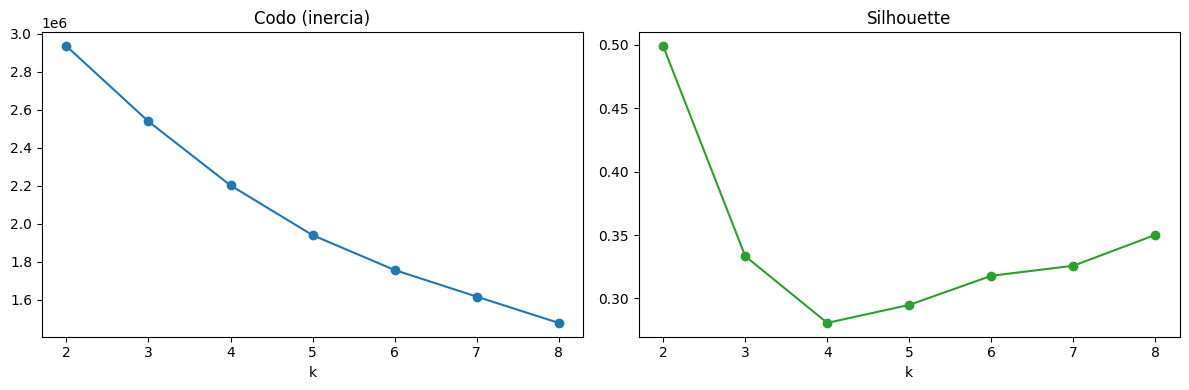

k=2: silhouette=0.499
k=3: silhouette=0.333
k=4: silhouette=0.281
k=5: silhouette=0.295
k=6: silhouette=0.318
k=7: silhouette=0.326
k=8: silhouette=0.350


In [4]:
ks = range(2, 9)
inertias, sils = [], []
sub = Xs[np.random.RandomState(RANDOM_STATE).choice(len(Xs), 10_000, replace=False)]
for k in ks:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(Xs)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(sub, km.predict(sub)))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(list(ks), inertias, "o-"); ax[0].set_title("Codo (inercia)"); ax[0].set_xlabel("k")
ax[1].plot(list(ks), sils, "o-", color="tab:green"); ax[1].set_title("Silhouette"); ax[1].set_xlabel("k")
plt.tight_layout(); plt.show()
for k, s in zip(ks, sils): print(f"k={k}: silhouette={s:.3f}")

## 4. KMeans (k=4)

Cuatro grupos muy desiguales: **C0 = 42.6%, C2 = 49.4%, C1 = 7.9%** y C3 = 0.04% (123 sesiones). Los dos grandes se reparten casi todo el tráfico; C1 es un nicho y C3 es residual (resulta ser ruido, se ve en el perfilado).

In [5]:
km = KMeans(n_clusters=K_FINAL, random_state=RANDOM_STATE, n_init=10).fit(Xs)
samp = samp.copy()
samp["cluster"] = km.labels_
print(samp["cluster"].value_counts().sort_index())

cluster
0    127883
1     23703
2    148291
3       123
Name: count, dtype: int64


## 5. Perfilado de clusters

Cada cluster es un tipo de visitante reconocible:

- **C0 — Comprador de electrónica de alto valor** (42.6%, conversión 7.5%). Foco casi total en electrónica (91.5%), precio alto (~$504), pocas vistas (2.9) y productos (2), decide en ~10 min. Mira poco pero compra más que nadie → el premio.
- **C2 — Comprador general de bajo valor** (49.4%, conversión 5.0%). Casi nada de electrónica (1.4%), precio bajo (~$152). Mucho volumen, poco valor por compra.
- **C1 — Explorador que no cierra** (7.9%, conversión 2.9%, la más baja). Navega muchísimo (17.5 vistas, 11.8 productos, 26 min) pero es el que menos compra. Confirma el hallazgo del EDA: más navegación ≠ más compra.
- **C3 — Sesiones anómalas** (123 sesiones, 0% conversión). Duración media ~15 días: sesiones rotas que nunca cerraron. Es un hallazgo de calidad de datos, no un segmento.

> **Insight:** el valor no está en quien más navega (C1), sino en el comprador de electrónica rápido y enfocado (C0) — coincide con el EDA y con las features top del modelo de propensión (`max_price_viewed`, `electronics_view_share`). Funnel, modelo y clustering apuntan al mismo lugar.

In [6]:
perfil = (samp.groupby("cluster")
          .agg(n=("target_purchase", "size"),
               conversion=("target_purchase", "mean"),
               electronics=("electronics_view_share", "mean"),
               precio_medio=("avg_price_viewed", "mean"),
               precio_max=("max_price_viewed", "mean"),
               vistas=("total_views", "mean"),
               productos=("distinct_products_viewed", "mean"),
               revisita=("revisit_intensity", "mean"),
               duracion_s=("browsing_duration_sec", "mean"))
          .assign(pct=lambda d: (d["n"]/d["n"].sum()*100).round(1)))
perfil = perfil.round(3).sort_values("conversion", ascending=False)
print(perfil)

              n  conversion  electronics  precio_medio  precio_max  vistas  \
cluster                                                                      
0        127883       0.075        0.915       504.000  594.223999   2.861   
2        148291       0.050        0.014       151.821  181.947006   2.856   
1         23703       0.029        0.214       253.995  670.835022  17.514   
3           123       0.000        0.482       275.703  302.174011   5.992   

         productos  revisita   duracion_s   pct  
cluster                                          
0            2.015     1.372      633.843  42.6  
2            2.047     1.344      577.194  49.4  
1           11.819     1.486     1562.114   7.9  
3            1.463     5.171  1312389.098   0.0  


## 6. El cruce: tipo de visitante × propensión → segmento objetivo

El scatter cruza conversión (propensión del segmento) × valor (electrónica×precio), tamaño = % de tráfico. **C0 domina las dos dimensiones a la vez** (alta conversión y alto valor) y además es grande (42.6%): el único que combina propensión + valor + volumen. C2 es enorme pero de valor casi nulo; C1 abajo (baja conversión); C3 insignificante. El **segmento objetivo del A/B es C0**. Y la oportunidad: aun siendo el que más convierte, el 92.5% de C0 no compra → un gran pool de alto valor recuperable (palanca A del EDA: carritos de electrónica, ~$211M en juego).

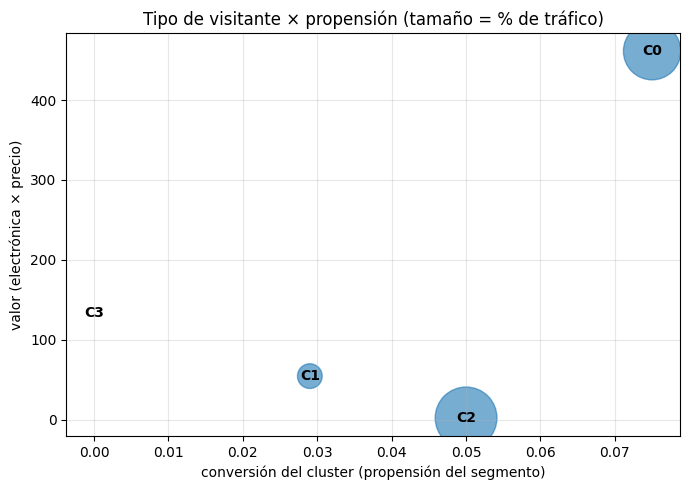

          pct  conversion  electronics  precio_medio  valor
cluster                                                    
0        42.6       0.075        0.915       504.000  461.2
2        49.4       0.050        0.014       151.821    2.1
1         7.9       0.029        0.214       253.995   54.4
3         0.0       0.000        0.482       275.703  132.9


In [7]:
# Proxy de oportunidad: volumen × valor (electrónica×precio). Conversión alta+volumen+valor = premio.
perfil["valor"] = (perfil["electronics"] * perfil["precio_medio"]).round(1)
plt.figure(figsize=(7,5))
plt.scatter(perfil["conversion"], perfil["valor"], s=perfil["pct"]*40, alpha=.6)
for c, r in perfil.iterrows():
    plt.annotate(f"C{c}", (r["conversion"], r["valor"]), ha="center", va="center", fontweight="bold")
plt.xlabel("conversión del cluster (propensión del segmento)")
plt.ylabel("valor (electrónica × precio)"); plt.title("Tipo de visitante × propensión (tamaño = % de tráfico)")
plt.grid(alpha=.3); plt.tight_layout(); plt.show()
print(perfil[["pct","conversion","electronics","precio_medio","valor"]])

### Proyección PCA — diagnóstico visual del clustering

Proyección 2D del clustering para inspección. Los loadings confirman que los visitantes se separan en dos dimensiones: **PC1 = amplitud de navegación** (vistas, productos y marcas distintas) y **PC2 = nivel de precio / foco en electrónica** (precio visto y % electrónica). Los grupos no se distinguen por cuándo entran, sino por qué tan amplio navegan y qué tan caro/electrónico es lo que miran.

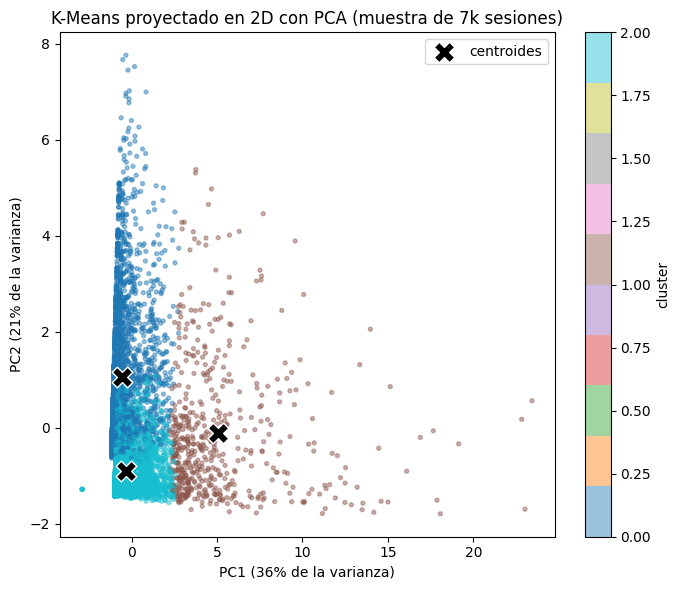

Varianza capturada por PC1+PC2: 0.57


In [ ]:
from sklearn.decomposition import PCA

# Quitar outliers (duración > 1 día) para que no aplasten la proyección
mask  = (samp["browsing_duration_sec"] < 86400).values
Xs_v  = Xs[mask]
lab_v = km.labels_[mask]

pca = PCA(n_components=2, random_state=RANDOM_STATE)
P    = pca.fit_transform(Xs_v)
present = np.unique(lab_v)
cent = pca.transform(km.cluster_centers_[present])   # centroides proyectados

# Submuestra para que el scatter no sea un borrón
idx = np.random.RandomState(RANDOM_STATE).choice(len(P), size=min(7000, len(P)), replace=False)

plt.figure(figsize=(7,6))
sc = plt.scatter(P[idx,0], P[idx,1], c=lab_v[idx], cmap="tab10", s=8, alpha=.45)
plt.scatter(cent[:,0], cent[:,1], c="black", marker="X", s=220, edgecolor="white", label="centroides")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.0f}% de la varianza)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.0f}% de la varianza)")
plt.title("K-Means proyectado en 2D con PCA (muestra de 7k sesiones)")
plt.legend(); plt.colorbar(sc, label="cluster"); plt.tight_layout(); plt.show()
print("Varianza capturada por PC1+PC2:", round(pca.explained_variance_ratio_[:2].sum(), 3))

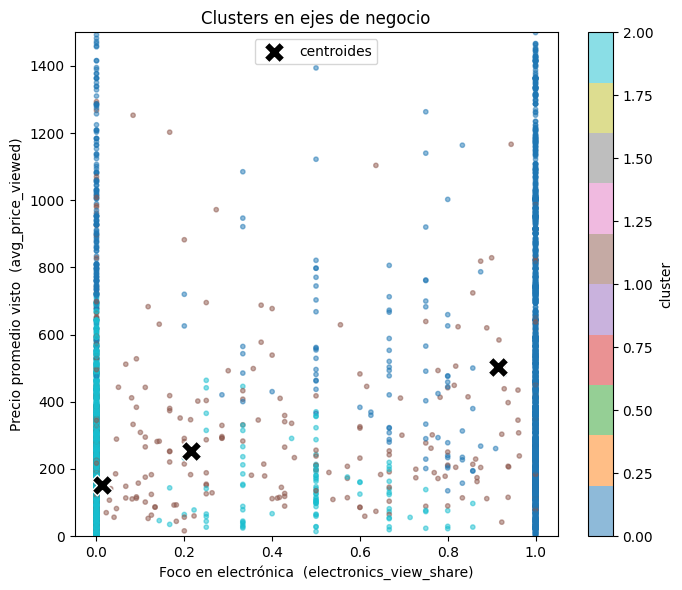

In [ ]:
mask = (samp["browsing_duration_sec"] < 86400).values
d   = samp[mask]
sub = d.sample(min(7000, len(d)), random_state=RANDOM_STATE)

plt.figure(figsize=(7,6))
sc = plt.scatter(sub["electronics_view_share"], sub["avg_price_viewed"],
                 c=sub["cluster"], cmap="tab10", s=10, alpha=.5)
cen = d.groupby("cluster")[["electronics_view_share","avg_price_viewed"]].mean()
plt.scatter(cen["electronics_view_share"], cen["avg_price_viewed"],
            c="black", marker="X", s=220, edgecolor="white", label="centroides")
plt.xlabel("Foco en electrónica  (electronics_view_share)")
plt.ylabel("Precio promedio visto  (avg_price_viewed)")
plt.title("Clusters en ejes de negocio")
plt.legend(); plt.colorbar(sc, label="cluster")
plt.ylim(0, 1500)   # recorta la cola de precios si hace falta
plt.tight_layout(); plt.show()

In [ ]:
import pandas as pd
load = pd.DataFrame(pca.components_.T, index=CLUSTER_FEATURES, columns=["PC1","PC2"])
print(load.round(2).reindex(load["PC1"].abs().sort_values(ascending=False).index))

                           PC1   PC2
distinct_products_viewed  0.47  0.01
brands_compared           0.47 -0.06
total_views               0.45  0.01
categories_explored_cid   0.43 -0.04
categories_explored       0.37 -0.03
max_price_viewed          0.13  0.64
electronics_view_share   -0.09  0.38
revisit_intensity         0.07 -0.01
avg_price_viewed         -0.01  0.66
views_per_minute          0.01  0.02
browsing_duration_sec     0.01  0.00
avg_inter_event_sec       0.00  0.00


### Clusters en ejes de negocio: foco en electrónica × precio

Los mismos clusters en ejes interpretables — foco en electrónica (X) vs precio promedio visto (Y). Las X negras (centroides) cuentan la historia: **C2 abajo-izquierda** (~$152, sin electrónica), C1 en el medio, y **C0 arriba-derecha** (~$504, electrónica pura). Las rayas verticales son normales: `electronics_view_share` es una fracción sobre pocos productos, lo que concentra los puntos en valores discretos.

## 7. Nombrar los segmentos (cluster ≠ segmento) y handoff

Un *cluster* es un grupo que encontró el algoritmo; un *segmento* es un grupo que podemos **nombrar, dimensionar, perfilar y tratar distinto**. Aquí bautizamos cada cluster y elegimos el objetivo del A/B.

| Cluster | Segmento | Perfil | Conversión | % tráfico | Acción |
|---|---|---|---|---|---|
| **C0** | **Comprador de electrónica de alto valor** | electrónica, precio alto, decide rápido | **7.5%** | 42.6% | 🎯 **A/B: incentivo inmediato** |
| C2 | Comprador general de bajo valor | categorías baratas, mucho volumen | 5.0% | 49.4% | no priorizar (poco valor) |
| C1 | Explorador que no cierra | navega muchísimo, no compra | 2.9% | 7.9% | observar (otra mecánica) |
| C3 | Sesiones anómalas | sesiones rotas (~15 días) | 0% | 0.04% | depurar (calidad de datos) |

**Segmento objetivo del A/B: C0.** Es el único que combina **alta propensión + alto valor + volumen accionable**. Aun siendo el que más convierte, el **92.5% de C0 no compra** → un gran pool de alto valor *recuperable* (palanca A del EDA: carritos de electrónica, ~$211M en juego).

Yeison dirige el incentivo a este grupo y el modelo de propensión (notebook 02) hace el *targeting* fino **dentro** de C0. El segmento pasa al **Contrato 2** (`user_session`, probabilidad calibrada, **segmento**), que se persiste en Delta (notebook 06) y alimenta a Kelly (tablero) y Yeison (A/B).

> **Nota de calidad de datos:** C3 (123 sesiones con duración de ~15 días) son sesiones anómalas/rotas, no un segmento de negocio; quedan aisladas y no contaminan al resto.

> **Nota de alcance:** se clusteriza por **comportamiento de sesión**, no por RFM de usuario (la Gold es por sesión, sin historia de compras por persona). La continuidad entre sesiones queda como extensión futura.